## Introduction to Word Embeddings

In [ ]:
! pip install spacy

Defaulting to user installation because normal site-packages is not writeable
  Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached preshed-3.0.13-cp312-cp312-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached srsly-2.5.3-cp312-cp312-win_amd64.whl.metadata (20 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl (14.2 MB)
Using cached preshed-3.0.13-cp312-cp312-win_amd64.whl (122 kB)
Using cached srsly-2.5.3-cp312-cp312-win_amd64.whl (652 kB)
Using cached thinc-8.3.13-cp312-cp312-win_amd64.whl (1.7 MB)
Using cached typer-0.25.1-py3-none-any.whl (58 kB)
Using cached weasel-1.0.0-py3-none-any.whl (50 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\haris\\AppData\\Roaming\\Python\\Python312\\site-packages\\thinc\\tests\\layers\\test_with_flatten.py'
Check the permissions.



In [6]:
import os
import csv
import spacy

class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename,"r",encoding="utf-8") as i:
            reader=csv.reader(i,delimiter=",")
            for _, abstract in reader:
                tokens=[t.text.lower() for t in self.nlp(abstract)]
                yield tokens
documents=Corpus("arxiv.csv")

In [7]:
documents

## Tokenization

In [8]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [10]:
! pip install spacy gensim

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/45.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/45.9 MB ? eta -:--:--
    --------------------------------------- 0.8/45.9 MB 3.0 MB/s eta 0:00:15
   - -------------------------------------- 1.3/45.9 MB 2.8 MB/s eta 0:00:16
   - -------------------------------------- 1.8/45.9 MB 2.6 MB/s eta 0:00:17
   -- ------------------------------------- 2.4/45.9 MB 2.7 MB/s eta 0:00:17
   -- ------------------------------------- 2.6/45.9 MB 2.3 MB/s eta 0:00:19
   -- ------------------------------------- 3.4/45.9 MB 2.5 MB/s eta 0:00:17
   --- ------------------------------------ 4.2/45.9 MB 2.6 MB/s eta 0:00:16
   ---- ----------------------------------- 4.7/45.9 MB 2.6 MB/s eta 0:00:16
   ---- ----------------------------------- 5.0/45.9 MB 2.6 MB/s eta 0:00:16
   ---- ----------------------------------- 5.5/45.9 MB 2.5 MB/s eta 0:00:17
   ----- ---

## Vectorization

In [12]:
import gensim

model=gensim.models.Word2Vec(documents, min_count=100 , window=5 ,vector_size=100)

## Using Word Embeddings

In [14]:
model.wv["nlp"]

array([ 0.07740816, -1.5756817 ,  1.1205653 , -0.14318947,  1.0477159 ,
        1.5651845 ,  1.789787  , -0.41444597, -0.39680853,  1.2974995 ,
        0.22376281, -2.2152913 ,  0.8216443 ,  0.8183672 ,  1.3602008 ,
        0.7091281 , -0.31618196,  2.2298846 , -0.7515883 ,  2.4205456 ,
        1.8320913 ,  0.5444788 ,  0.60317147,  0.77446884, -2.3628159 ,
       -2.1683102 , -0.25745863,  0.29330012,  2.5405893 , -1.6519454 ,
        0.3862667 ,  0.16865636,  1.4142494 ,  1.3171237 ,  2.0356674 ,
       -1.1531384 ,  0.421237  , -3.911568  , -0.77910507,  2.6793227 ,
       -1.2658045 , -1.9851859 ,  3.5207653 ,  0.34775865, -2.541871  ,
        0.57349485,  1.1927717 ,  0.8611051 , -0.4315485 , -1.6636941 ,
        1.4014753 ,  2.349329  ,  0.4016226 , -0.22751541, -0.67719114,
       -0.44444478, -0.39533606,  1.2638994 ,  3.2545977 ,  0.01769589,
       -0.14679039,  1.9723462 , -1.4624463 ,  0.3063189 , -0.13462318,
       -0.7086734 , -1.7877305 , -1.6814005 ,  0.46918592,  0.30

In [16]:
print(model.wv.similarity("nmt","smt"))
print(model.wv.similarity("nmt","ner"))

0.63419014
0.39408344


In [17]:
model.wv.similar_by_word("best", topn=10)

[('highest', 0.6245850324630737),
 ('competitive', 0.5555920600891113),
 ('sota', 0.5077526569366455),
 ('superior', 0.5066381096839905),
 ('comparable', 0.492118775844574),
 ('top', 0.49124401807785034),
 ('par', 0.48745453357696533),
 ('final', 0.48701193928718567),
 ('better', 0.4734480679035187),
 ('good', 0.4650949239730835)]

In [ ]:
model.wv.most_similar(positive=["transformer","lstm"], negative=["best"], topn=10)

[('rnn', 0.7651100754737854),
 ('gru', 0.7258236408233643),
 ('lstms', 0.7008517384529114),
 ('recurrent', 0.696634829044342),
 ('transformers', 0.6943463683128357),
 ('encoder', 0.6667222380638123),
 ('convolution', 0.6627115607261658),
 ('convolutional', 0.6470434069633484),
 ('gated', 0.640360951423645),
 ('bilstm', 0.639769971370697)]

In [20]:
model.wv.most_similar(positive=["tree"],topn=10)

[('trees', 0.7964836359024048),
 ('constituency', 0.7277282476425171),
 ('parse', 0.7028217911720276),
 ('recursive', 0.6597316265106201),
 ('dependency', 0.654849112033844),
 ('syntax', 0.6285127401351929),
 ('parser', 0.6107190251350403),
 ('constituent', 0.6101769208908081),
 ('transition', 0.6067636013031006),
 ('grammars', 0.602705180644989)]

In [22]:
print(model.wv.doesnt_match("lst cm gru svm transformer".split()))
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))

svm
word2vec
bert


## Plotting Embeddings

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word],topn=200)]+ [target_word]
embeddings = [model.wv[w] for w in selected_words ]+ model.wv["bert"]

mapped_embeddings = TSNE(n_components=2,metric='cosine',init='pca').fit_transform(embeddings)

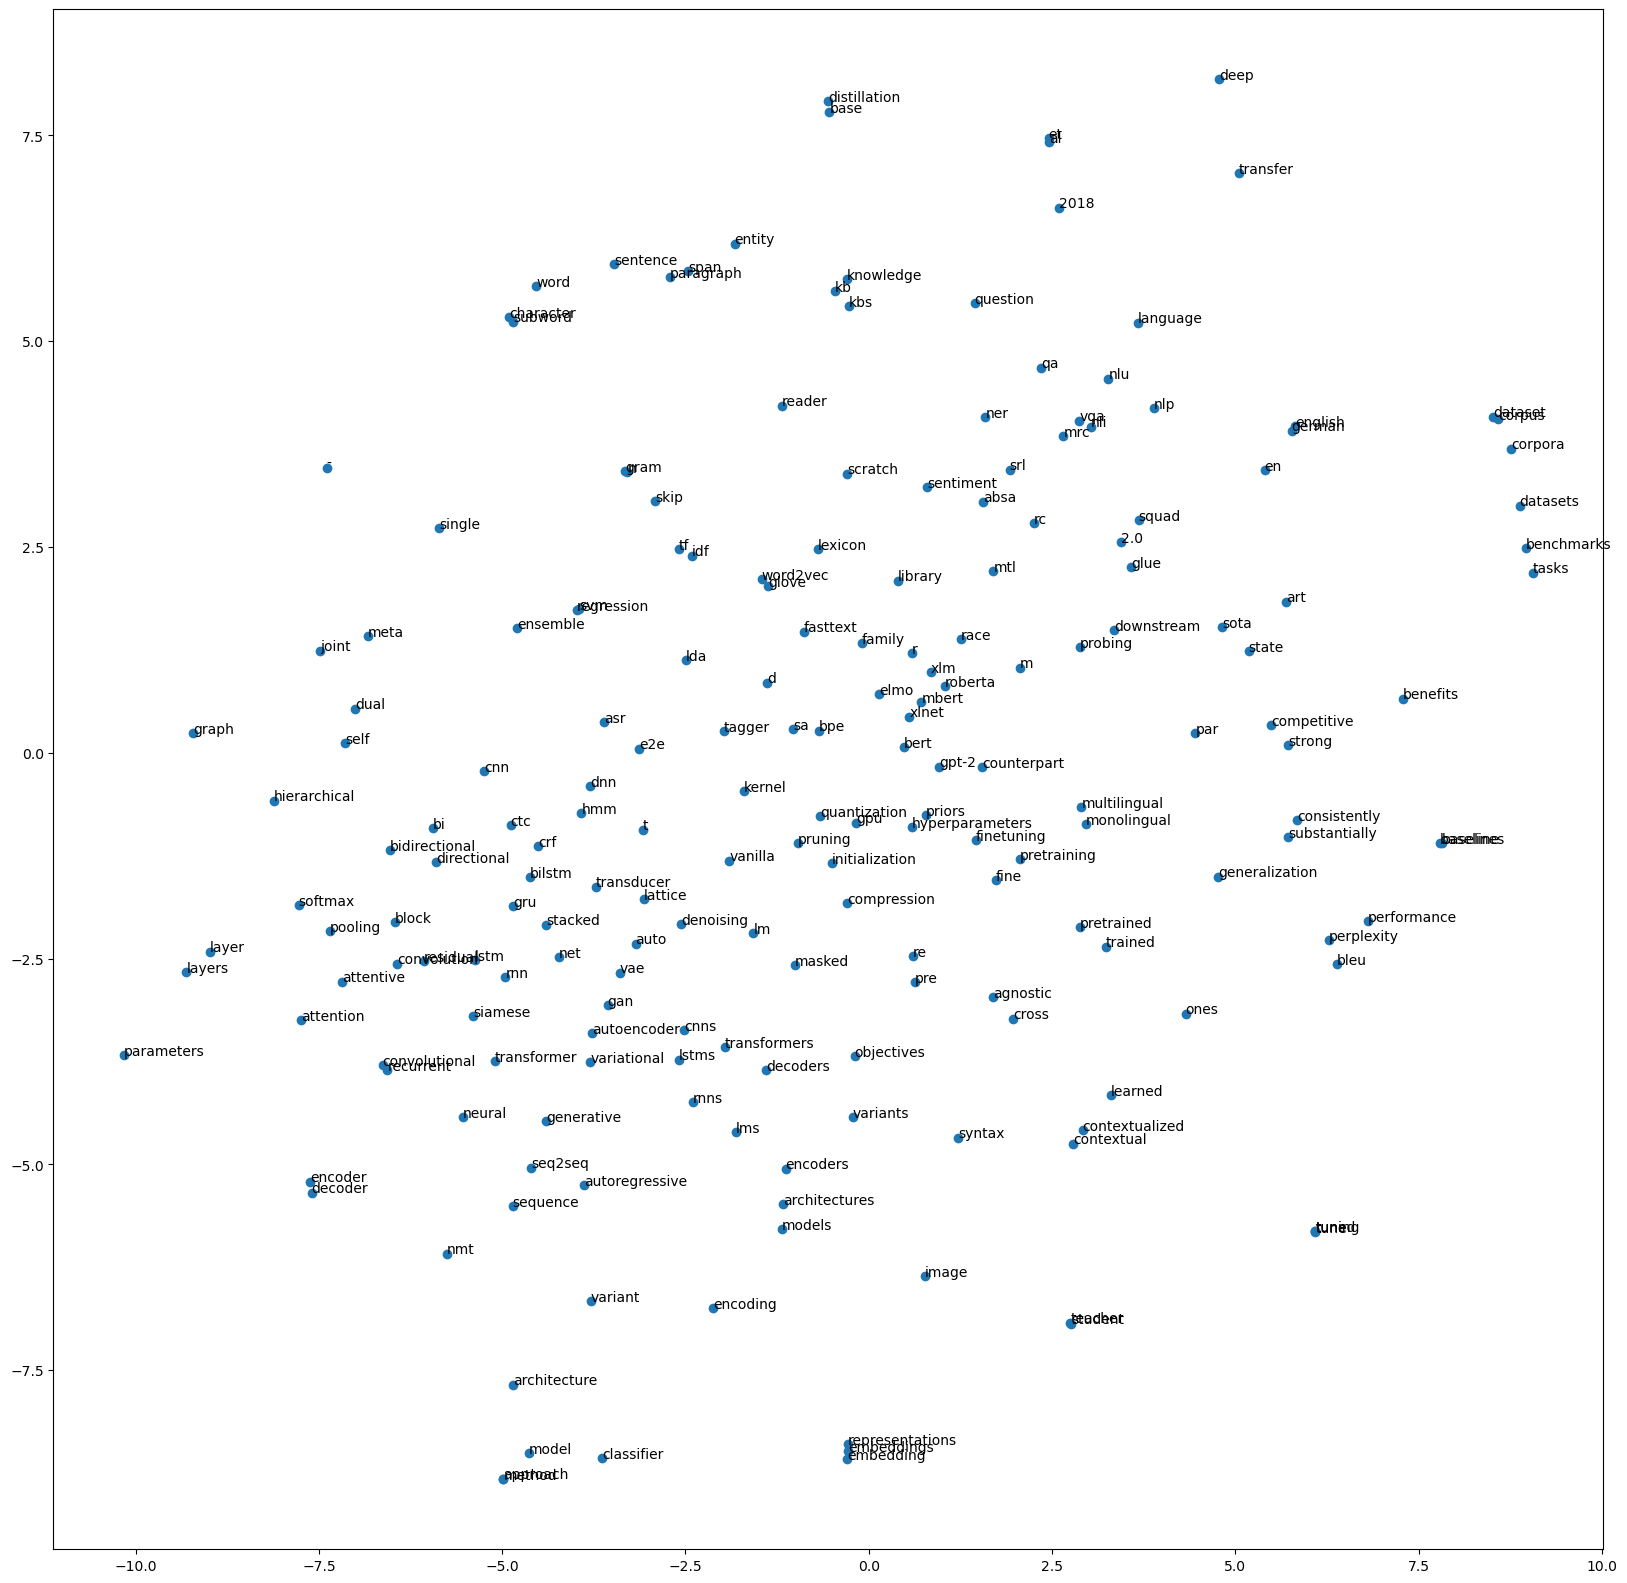

In [26]:
plt.figure(figsize=(20,20))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)

for i, txt in enumerate(selected_words):
    plt.annotate(txt,(x[i],y[i]))